# Uniform Quantization & MSQE Analysis

Demonstrates uniform quantization of a grayscale image to $L$ gray levels using the formula:

$$q(r) = \lfloor r / \Delta \rfloor \cdot \Delta + \frac{\Delta}{2} \quad \text{where } \Delta = \frac{256}{L}$$

Shows quantized images for $L = 2 \dots 256$ in a matplotlib grid and plots MSQE vs. $L$.


In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## (i) Vectorized Quantization Function


In [2]:
def quantize(img, L):
    """
    Uniformly quantize an 8-bit grayscale image to L gray levels.

    q(r) = floor(r / delta) * delta + delta/2,   delta = 256 / L
    """
    img_f = img.astype(np.float64)  # avoid uint8 overflow during math
    delta = 256.0 / L

    bin_index = np.floor(img_f / delta)  # floor(r / delta), vectorized
    q = bin_index * delta + delta / 2.0  # midpoint of each bin

    q = np.round(q)  # round after all calculations
    q = np.clip(q, 0, 255)  # safety clip (guards float edge cases)

    return q.astype(np.uint8)

## (ii) Read Grayscale Image & Compute Quantized Versions


In [3]:
image_path = "images/image1.jpg"
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

L_values = [2, 4, 8, 16, 32, 64, 128, 256]

if img is not None:
    quantized_images = {L: quantize(img, L) for L in L_values}
else:
    print(f"Error: Could not load image from '{image_path}'")

## (iii) Display Quantized Images in a Grid


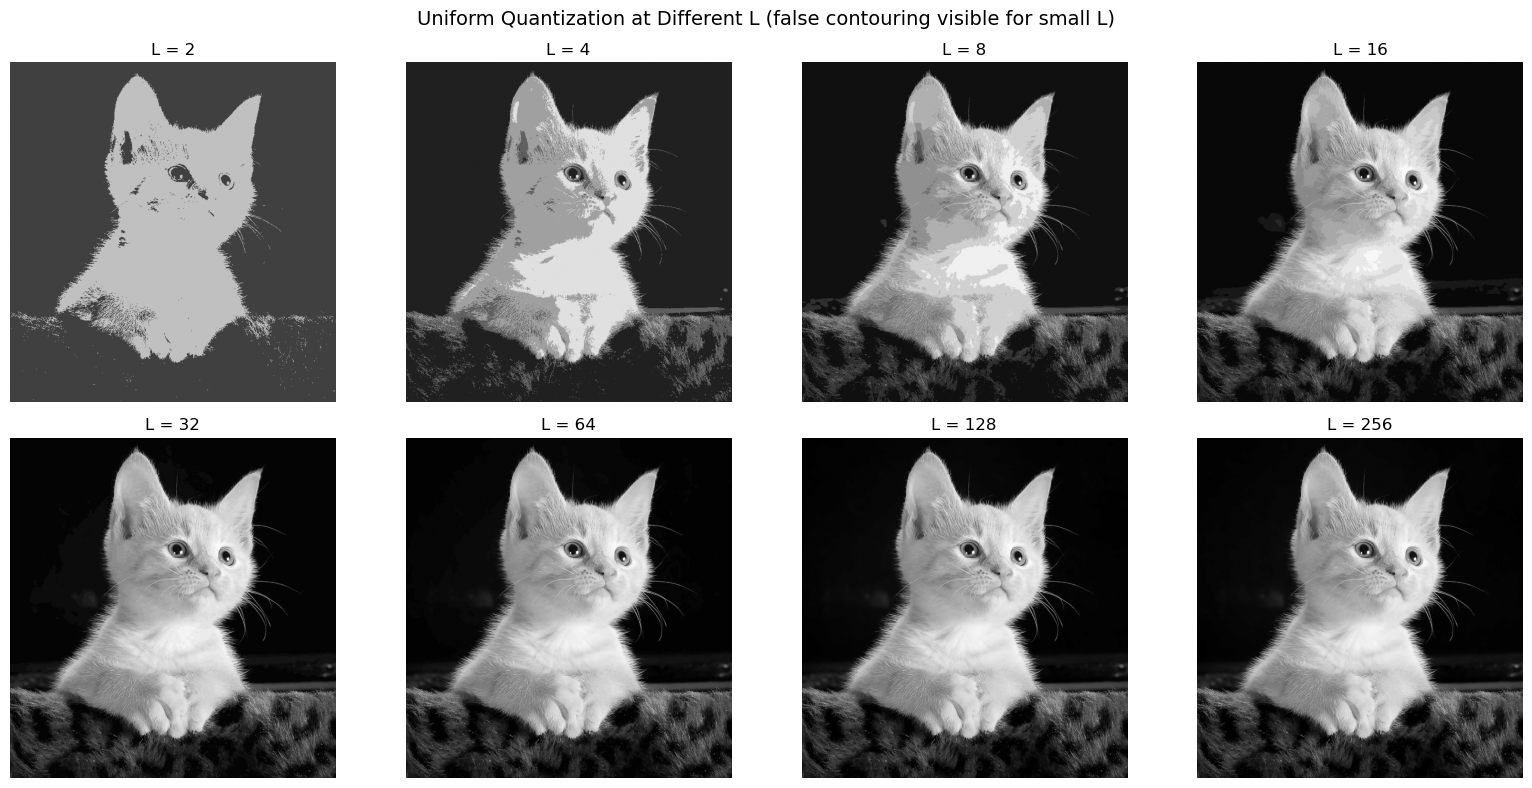

In [4]:
if img is not None:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    for ax, L in zip(axes, L_values):
        ax.imshow(quantized_images[L], cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"L = {L}")
        ax.axis("off")

    fig.suptitle(
        "Uniform Quantization at Different L (false contouring visible for small L)",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()

## (iv) MSQE Calculation & Plot (MSQE vs. L)



MSQE per level:
  L =   2  ->  MSQE = 2245.078
  L =   4  ->  MSQE = 508.554
  L =   8  ->  MSQE = 109.330
  L =  16  ->  MSQE = 21.675
  L =  32  ->  MSQE = 5.151
  L =  64  ->  MSQE = 1.416
  L = 128  ->  MSQE = 0.494
  L = 256  ->  MSQE = 0.506


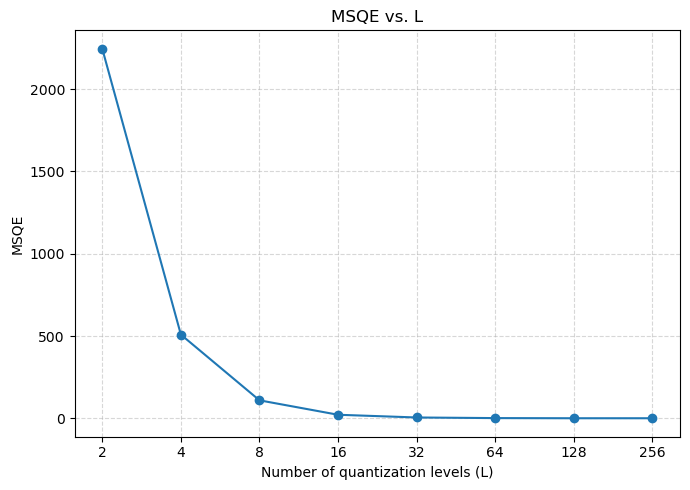

In [5]:
def msqe(original, quantized):
    """Mean Squared Quantization Error between two same-shape uint8 images."""
    orig_f = original.astype(np.float64)
    quant_f = quantized.astype(np.float64)
    error = orig_f - quant_f
    return np.mean(error**2)


if img is not None:
    msqe_values = [msqe(img, quantized_images[L]) for L in L_values]

    print("\nMSQE per level:")
    for L, e in zip(L_values, msqe_values):
        print(f"  L = {L:>3}  ->  MSQE = {e:.3f}")

    plt.figure(figsize=(7, 5))
    plt.plot(L_values, msqe_values, marker="o")
    plt.xscale("log", base=2)
    plt.xticks(L_values, [str(L) for L in L_values])
    plt.xlabel("Number of quantization levels (L)")
    plt.ylabel("MSQE")
    plt.title("MSQE vs. L")
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

## (v) Discussion: Trend of MSQE vs. L and Connection to Part (a)

The MSQE-vs-L plot decreases sharply and monotonically as $L$ increases. This follows directly from the formula: $\Delta = 256 / L$, so larger $L$ means a smaller step size $\Delta$, meaning each pixel is quantized to a value much closer to its true intensity. Since MSQE is dominated by $\Delta^2$-scale rounding error, doubling $L$ roughly quarters the MSQE (MSQE decreases approximately as $1 / L^2$) — the curve drops steeply between $L = 2$ and $L = 16$, then flattens out and approaches 0 as $L$ approaches 256 (no quantization loss at all, since 256 levels exactly matches 8-bit precision).

This matches the hand-computed result from part (a): for the 8 sample pixel values quantized to $L = 4$, the MSQE was 433.0, a large error caused by the coarse 64-wide bins. In this program's plot, the $L = 4$ point on the curve sits at a similarly high MSQE value near the steep, high-error end of the curve, while $L = 256$ sits at (or near) $\text{MSQE} = 0$.

The visual counterpart of this numerical trend is that images quantized with small $L$ (e.g. $L = 2, 4$) show strong **false contouring / posterization** — visible banding where smooth gradients used to be — while by $L = 32$ or higher the image is visually almost indistinguishable from the original.
